In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_csv(r"C:\Users\Reference\Downloads\cleaned_dataset.csv")
df.head()

,property_name,areaWithType,square_feet,transaction,status,floor,furnishing,facing,price_per_sqft,price,floor_number
0,2 BHK Apartment for Sale in Dindoli Surat,Carpet Area,644.0,New Property,Poss. by Oct '24,5 out of 10,Unfurnished,West,2891.0,33.8,5.0
1,2 BHK Apartment for Sale in Althan Surat,Super Area,1278.0,New Property,Poss. by Jan '26,6 out of 14,Unfurnished,South -West,3551.0,45.4,6.0
2,2 BHK Apartment for Sale in Pal Gam Surat,Super Area,1173.0,Resale,Ready to Move,5 out of 13,Semi-Furnished,East,3800.0,44.6,5.0
3,2 BHK Apartment for Sale in Jahangirabad Surat,Carpet Area,700.0,New Property,Ready to Move,6 out of 14,Unfurnished,East,3966.0,47.0,6.0
4,"2 BHK Apartment for Sale in Orchid Fantasia, P...",Super Area,1250.0,Orchid Fantasia,New Property,Unfurnished,Unknown,Unknown,3600.0,45.0,5.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4399 entries, 0 to 4398
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   property_name   4399 non-null   object 
 1   areaWithType    4399 non-null   object 
 2   square_feet     4399 non-null   float64
 3   transaction     4399 non-null   object 
 4   status          4399 non-null   object 
 5   floor           4399 non-null   object 
 6   furnishing      4399 non-null   object 
 7   facing          4399 non-null   object 
 8   price_per_sqft  4399 non-null   float64
 9   price           4399 non-null   float64
 10  floor_number    4399 non-null   float64
dtypes: float64(4), object(7)
memory usage: 378.2+ KB


In [6]:
#Machine learning models cannot understand text, so convert categorical columns into numbers
df_encoded = pd.get_dummies(
    df,
    columns=["transaction", "status", "furnishing", "facing"],
    drop_first=True
)

df_encoded.head()

,property_name,areaWithType,square_feet,floor,price_per_sqft,price,floor_number,transaction_1 Covered,transaction_10 m,transaction_2,...,facing_Vaishnodevi Amour Jahagirabad,facing_Vaishnodevi Ideal Homes,facing_Varni Siddheshwar Heights,facing_Vasant Vihar Township,facing_Vesu Point,facing_Vibrant Eco Park,facing_Vitthal Bunglows,facing_West,facing_Yes,facing_aventis ofira
0,2 BHK Apartment for Sale in Dindoli Surat,Carpet Area,644.0,5 out of 10,2891.0,33.8,5.0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,2 BHK Apartment for Sale in Althan Surat,Super Area,1278.0,6 out of 14,3551.0,45.4,6.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2 BHK Apartment for Sale in Pal Gam Surat,Super Area,1173.0,5 out of 13,3800.0,44.6,5.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2 BHK Apartment for Sale in Jahangirabad Surat,Carpet Area,700.0,6 out of 14,3966.0,47.0,6.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,"2 BHK Apartment for Sale in Orchid Fantasia, P...",Super Area,1250.0,Unfurnished,3600.0,45.0,5.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [7]:
#Select Features and Target Variable
X = df_encoded.drop(["price", "property_name", "areaWithType", "floor"], axis=1)
y = df_encoded["price"]

print(X.head())

   square_feet  price_per_sqft  floor_number  transaction_1 Covered  \
0        644.0          2891.0           5.0                  False   
1       1278.0          3551.0           6.0                  False   
2       1173.0          3800.0           5.0                  False   
3        700.0          3966.0           6.0                  False   
4       1250.0          3600.0           5.0                  False   

   transaction_10 m  transaction_2  transaction_20 Covered,  transaction_3  \
0             False          False                    False          False   
1             False          False                    False          False   
2             False          False                    False          False   
3             False          False                    False          False   
4             False          False                    False          False   

   transaction_3 Covered  transaction_4  ...  \
0                  False          False  ...   
1       

In [8]:
#Split data for training and testing.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3519, 429)
(880, 429)


In [9]:
#Train the Model
#Using Linear Regression.
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
#Make Prediction
y_pred = model.predict(X_test)

print(y_pred[:10])

[54.09314568 59.36362526 63.89837358 40.05772228 49.37881547 34.64731263
 41.87164224 68.55230947 41.25987692 34.22139724]


In [11]:
#Evaluate the Model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 13.475840420580724
Mean Squared Error: 317.5527288887893
R2 Score: 0.11450963177455886


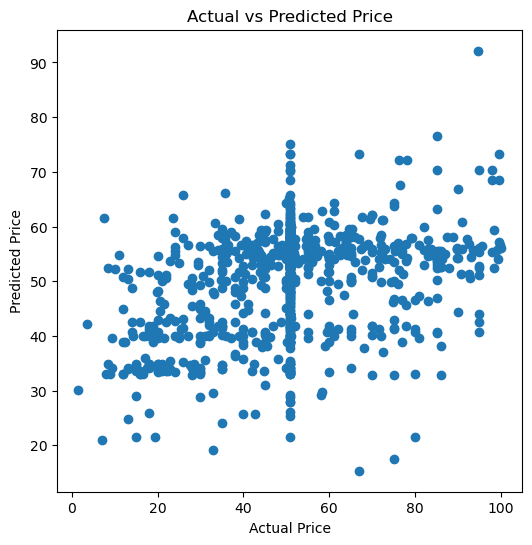

In [12]:
#Actual vs Predicted Visualization
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

In [13]:
#Feature Importance (Model Interpretation)
coefficients = pd.DataFrame(
    model.coef_,
    X.columns,
    columns=["Coefficient"]
)

coefficients.sort_values(by="Coefficient", ascending=False)

,Coefficient
status_Poss. by Dec '28,68.487872
status_45.5 X 21.56,63.985011
status_4 out of 14,61.191689
furnishing_10 m,59.380691
status_48 X 14,55.951967
...,...
facing_Royal Nest,-32.505880
facing_Satyam Tower,-35.334658
facing_Vibrant Eco Park,-35.855301
furnishing_Happy Glorious,-38.233274
